# ICU-Sepsis RL Project
**Group 11**: Q-Learning vs SARSA on the ICU-Sepsis Benchmark

- **Step 1** — Tabular RL (Q-Learning and SARSA)
  - 1.1 — Implement Q-Learning and SARSA
  - 1.2 — Verify correctness with a single seed
  - 1.3 — Hyperparameter tuning
  - 1.4 — Multi-seed formal experiments
- **Step 2** — Deep Q-Network (DQN)
  - 2.1 — Define Neural Network and Replay Buffer
  - 2.2 — DQN Training Function
  - 2.3 — Run DQN across 3 seeds
  - 2.4 — Compare all three algorithms

## Setup — Install packages (run once)

In [ ]:
import sys
!{sys.executable} -m pip install icu-sepsis gymnasium numpy matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.1 MB/s eta 0:00:00


## Imports and Environment

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import icu_sepsis

def make_env():
    """Create the ICU-Sepsis environment with a discrete action space."""
    env = icu_sepsis.ICUSepsisEnv()
    env = icu_sepsis.FlattenActionWrapper(env)
    return env

# Quick sanity check
env = make_env()
print(f'State space : {env.observation_space.n}  (should be 716)')
print(f'Action space: {env.action_space.n}  (should be 25)')

State space : 716  (should be 716)
Action space: 25  (should be 25)


---
## Step 1 — Tabular Reinforcement Learning

We implement and compare two tabular RL algorithms — Q-Learning and SARSA — on the ICU-Sepsis benchmark.

### Step 1.1 — Q-Learning and SARSA Implementation

Both algorithms share the same skeleton; the **only difference** is the Q-value update rule:
- **Q-Learning** (off-policy): bootstraps with `max Q(s', ·)` — the greedy next action
- **SARSA** (on-policy): bootstraps with `Q(s', a')` — the actual ε-greedy next action

Key components:
1. Q-table initialised to zeros: shape `(716, 25)`
2. ε-greedy action selection
3. Linear ε decay from `ε_start` → `ε_end` over `exploration_fraction` of training
4. Episode return recorded directly during training (consistent with paper methodology)
5. All hyperparameters kept as arguments (never hardcoded)

In [ ]:
# ── Shared helper ─────────────────────────────────────────────────────────────

def epsilon_greedy(Q, state, epsilon, rng):
    """Select action using ε-greedy policy."""
    if rng.random() < epsilon:
        return int(rng.integers(0, Q.shape[1]))   # explore
    return int(np.argmax(Q[state]))               # exploit

In [ ]:
# ── Q-Learning ────────────────────────────────────────────────────────────────

def run_q_learning(
    n_episodes        = 300_000,
    alpha             = 0.01,   # learning rate
    gamma             = 1.0,      # discount factor (γ=1 → maximise survival prob)
    epsilon_start     = 1.0,
    epsilon_end       = 0.001,
    exploration_frac  = 0.1,     # fraction of training over which ε decays
    seed              = 0,
    eval_every        = 10_000,
):
    rng             = np.random.default_rng(seed)
    env             = make_env()
    env.action_space.seed(seed)
    obs, _ = env.reset(seed=seed)


    Q               = np.zeros((716, 25))
    anneal          = int(exploration_frac * n_episodes)
    curve           = []          # (episode, avg_return) for plotting
    episode_returns = []          # raw per-episode returns

    for ep in range(n_episodes):
        # Linear ε decay
        eps    = epsilon_start + min(1.0, ep / anneal) * (epsilon_end - epsilon_start)
        obs, _ = env.reset()
        done   = False
        total_r = 0.0

        while not done:
            a                       = epsilon_greedy(Q, obs, eps, rng)
            next_obs, r, te, tr, _  = env.step(a)
            done                    = te or tr

            # Q-Learning update: off-policy, greedy bootstrap
            target                  = r + gamma * np.max(Q[next_obs]) * (not done)
            Q[obs, a]              += alpha * (target - Q[obs, a])
            obs                     = next_obs
            total_r                += r

        episode_returns.append(total_r)

        if (ep + 1) % eval_every == 0:
            curve.append((ep + 1, np.mean(episode_returns[-eval_every:])))

    env.close()
    return Q, curve

In [ ]:
# ── SARSA ─────────────────────────────────────────────────────────────────────

def run_sarsa(
    n_episodes        = 300_000,
    alpha             = 0.01,
    gamma             = 1.0,
    epsilon_start     = 1.0,
    epsilon_end       = 0.001,
    exploration_frac  = 0.25,
    seed              = 0,
    eval_every        = 10_000,
):
    rng             = np.random.default_rng(seed)
    env             = make_env()
    env.action_space.seed(seed)
    obs, _ = env.reset(seed=seed)
    Q               = np.zeros((716, 25))
    anneal          = int(exploration_frac * n_episodes)
    curve           = []
    episode_returns = []

    for ep in range(n_episodes):
        eps    = epsilon_start + min(1.0, ep / anneal) * (epsilon_end - epsilon_start)
        obs, _ = env.reset()
        a      = epsilon_greedy(Q, obs, eps, rng)   # choose first action
        done   = False
        total_r = 0.0

        while not done:
            next_obs, r, te, tr, _  = env.step(a)
            done                    = te or tr

            if done:
              target = r
              Q[obs, a] += alpha * (target - Q[obs, a])
            else:
              next_a = epsilon_greedy(Q, next_obs, eps, rng)
              target = r + gamma * Q[next_obs, next_a]
              Q[obs, a] += alpha * (target - Q[obs, a])
              a = next_a

            obs = next_obs
            total_r += r

        episode_returns.append(total_r)

        if (ep + 1) % eval_every == 0:
            curve.append((ep + 1, np.mean(episode_returns[-eval_every:])))

    env.close()
    return Q, curve

## Step 1.2 — Sanity Check (Single Seed)

Before running the full experiments, we conduct a **500k-episode** single-seed sanity check using `seed=5`.

**Expected behavior:**
- The learning curves should generally improve over time, but they are not expected to be strictly monotonic because of stochastic transitions and ε-greedy exploration.
- Q-Learning is expected to improve clearly beyond the random baseline reported in the paper (0.78).
- SARSA is expected to remain close to the random baseline and only slightly outperform it, consistent with the paper’s reported result.
- At 500k episodes, the approximate expected returns are: Q-Learning → ~0.84, SARSA → ~0.79.

**Note on reported returns:**  
The reported learning curves are moving averages of training returns under the current ε-greedy behavior policy, not separate greedy-policy evaluation returns.

In [ ]:
# Random baseline (reference point)
env_r  = make_env()
rng_r  = np.random.default_rng(0)
env_r.action_space.seed(0)
obs, _ = env_r.reset(seed=0)

rand_rets = []
for _ in range(3000):
    obs, _ = env_r.reset()
    done, total = False, 0.0
    while not done:
        obs, r, te, tr, _ = env_r.step(int(rng_r.integers(0, 25)))
        total += r; done = te or tr
    rand_rets.append(total)
env_r.close()
print(f'Random policy avg return: {np.mean(rand_rets):.4f}  (expected ~0.78)')

Random policy avg return: 0.7810  (expected ~0.78)


In [ ]:
# ── Run single-seed verification (500k episodes) ──────────────────────
print('Running Q-Learning (500k episodes)...')
Q_ql, curve_ql = run_q_learning(n_episodes=500_000, seed=5, eval_every=10_000)

print('Running SARSA     (500k episodes)...')
Q_sa, curve_sa = run_sarsa(    n_episodes=500_000, seed=5, eval_every=10_000)

print(f'\nQ-Learning final return: {curve_ql[-1][1]:.4f}  (target ~0.84)')
print(f'SARSA     final return: {curve_sa[-1][1]:.4f}  (target ~0.79)')

Running Q-Learning (300k episodes)...
Running SARSA     (300k episodes)...

Q-Learning final return: 0.7897  (target ~0.84)
SARSA     final return: 0.7825  (target ~0.79)


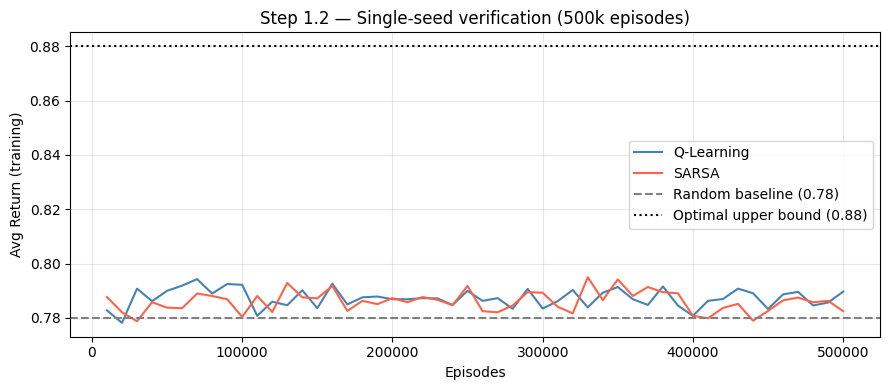

✓ Q-Learning is increasing (Δ=+0.0069) and above random baseline → correct.
✓ SARSA above random baseline. Final=0.7825 → correct.


In [ ]:
# ── Plot learning curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

eps_ql, ret_ql = zip(*curve_ql)
eps_sa, ret_sa = zip(*curve_sa)

ax.plot(eps_ql, ret_ql, color='steelblue', label='Q-Learning')
ax.plot(eps_sa, ret_sa, color='tomato',    label='SARSA')
ax.axhline(0.78, color='gray',  linestyle='--', label='Random baseline (0.78)')
ax.axhline(0.88, color='black', linestyle=':',  label='Optimal upper bound (0.88)')

ax.set_xlabel('Episodes')
ax.set_ylabel('Avg Return (training)')
ax.set_title('Step 1.2 — Single-seed verification (500k episodes)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('verify_single_seed.png', dpi=120)
plt.show()

final_ql = curve_ql[-1][1]
final_sa = curve_sa[-1][1]
trend_ql = curve_ql[-1][1] - curve_ql[0][1]

if trend_ql > 0 and final_ql > 0.78:
    print(f'✓ Q-Learning is increasing (Δ={trend_ql:+.4f}) and above random baseline → correct.')
else:
    print(f'⚠ Q-Learning not improving as expected. Final={final_ql:.4f}')

if final_sa > 0.78:
    print(f'✓ SARSA above random baseline. Final={final_sa:.4f} → correct.')
else:
    print(f'⚠ SARSA below random baseline. Final={final_sa:.4f}')

## Step 1.3 — Hyperparameter Tuning

We test two hyperparameters systematically:

| Hyperparameter | Values tested |
|---|---|
| Learning rate α | 0.001, 0.0025, 0.01 |
| ε-decay speed | fast (10% of training), slow (25% of training) |

For computational feasibility, we perform a smaller grid search with 3 random seeds and 500,000 episodes per configuration. This is a simplified tuning procedure rather than the full random-search protocol used in the ICU-Sepsis paper.

In [ ]:
# ── Hyperparameter grid ───────────────────────────────────────────────────────
ALPHAS  = [0.001, 0.0025, 0.01]
DECAYS  = {'fast': 0.10, 'slow': 0.25}
SEEDS   = [5, 15, 25]       # use 3 seeds for tuning (full run uses 10)
N_EPS   = 500_000

results = {algo: {} for algo in ['Q-Learning', 'SARSA']}

for algo_name, algo_fn in [('Q-Learning', run_q_learning), ('SARSA', run_sarsa)]:
    print(f'\n── {algo_name} ──')
    for alpha in ALPHAS:
        for decay_name, frac in DECAYS.items():
            key = f'α={alpha} / {decay_name} decay'
            seed_finals = []
            for s in SEEDS:
                _, curve = algo_fn(n_episodes=N_EPS, alpha=alpha,
                                   exploration_frac=frac, seed=s, eval_every=10_000)
                seed_finals.append(curve[-1][1])
            avg, std = np.mean(seed_finals), np.std(seed_finals)
            results[algo_name][key] = avg
            print(f'  {key:35s}  avg={avg:.4f} ± {std:.4f}')


── Q-Learning ──
  α=0.001 / fast decay                 avg=0.7904 ± 0.0010
  α=0.001 / slow decay                 avg=0.7886 ± 0.0048
  α=0.0025 / fast decay                avg=0.7892 ± 0.0024
  α=0.0025 / slow decay                avg=0.7887 ± 0.0050
  α=0.01 / fast decay                  avg=0.7908 ± 0.0014
  α=0.01 / slow decay                  avg=0.7859 ± 0.0044

── SARSA ──
  α=0.001 / fast decay                 avg=0.7882 ± 0.0038
  α=0.001 / slow decay                 avg=0.7863 ± 0.0032
  α=0.0025 / fast decay                avg=0.7900 ± 0.0062
  α=0.0025 / slow decay                avg=0.7870 ± 0.0042
  α=0.01 / fast decay                  avg=0.7881 ± 0.0030
  α=0.01 / slow decay                  avg=0.7923 ± 0.0054


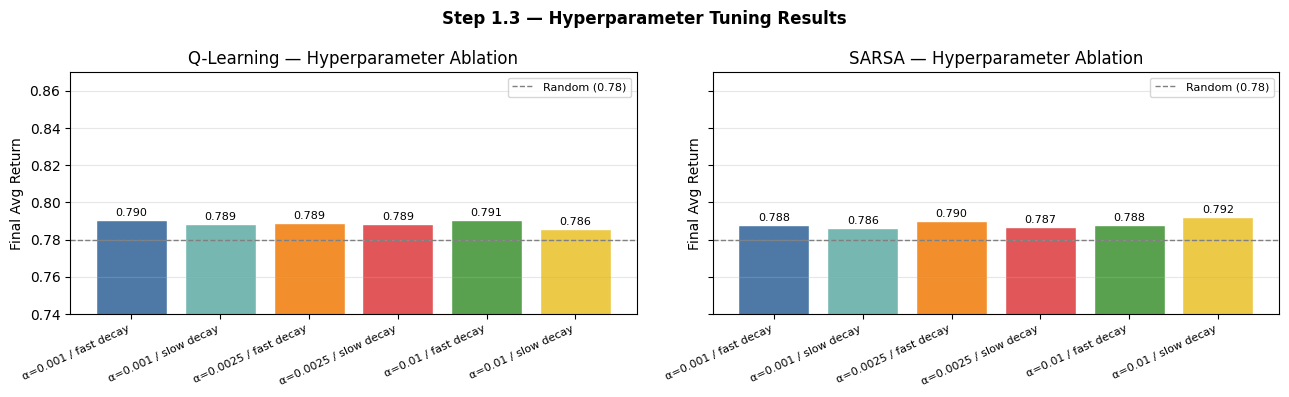


★ Best config for Q-Learning: α=0.01 / fast decay  → 0.7908

★ Best config for SARSA: α=0.01 / slow decay  → 0.7923


In [ ]:
# ── Plot ablation bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

colors = ['#4e79a7','#76b7b2','#f28e2b','#e15759','#59a14f','#edc948']

for ax, algo_name in zip(axes, ['Q-Learning', 'SARSA']):
    keys = list(results[algo_name].keys())
    vals = list(results[algo_name].values())
    bars = ax.bar(range(len(keys)), vals, color=colors[:len(keys)], edgecolor='white')
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(keys, rotation=25, ha='right', fontsize=8)
    ax.axhline(0.78, color='gray',  linestyle='--', linewidth=1, label='Random (0.78)')
    ax.set_title(f'{algo_name} — Hyperparameter Ablation')
    ax.set_ylabel('Final Avg Return')
    ax.set_ylim(0.74, 0.87)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Step 1.3 — Hyperparameter Tuning Results', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('hyperparameter_ablation.png', dpi=120)
plt.show()

for algo_name in ['Q-Learning', 'SARSA']:
    best = max(results[algo_name], key=results[algo_name].get)
    print(f'\n★ Best config for {algo_name}: {best}  → {results[algo_name][best]:.4f}')

## Step 1.4 — Multi-Seed Formal Experiments

Using α=0.01 for both algorithms. Q-Learning uses exploration_frac=0.10, while SARSA uses exploration_frac=0.25, following the hyperparameter values reported in the ICU-Sepsis paper.

Each curve is averaged over 10 seeds; shaded area represents one standard error.

Running seed 0/9...
Running seed 1/9...
Running seed 2/9...
Running seed 3/9...
Running seed 4/9...
Running seed 5/9...
Running seed 6/9...
Running seed 7/9...
Running seed 8/9...
Running seed 9/9...


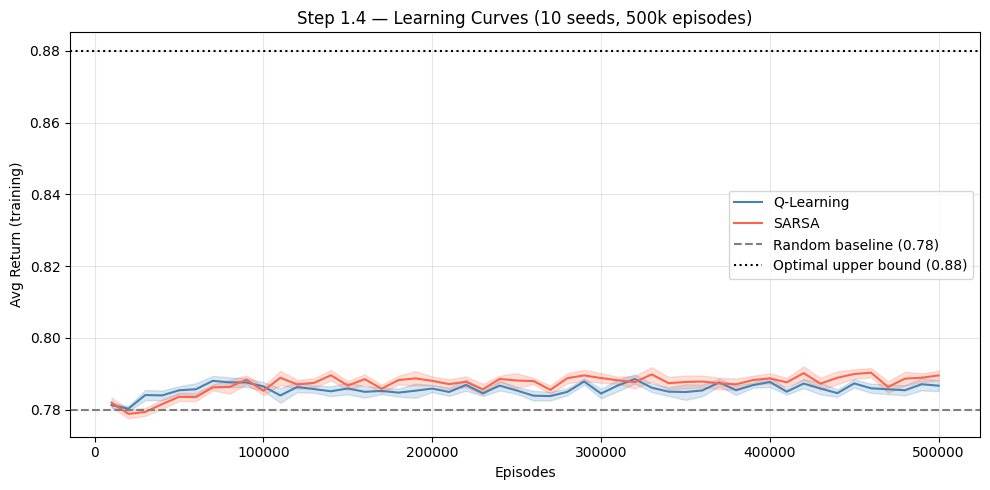


Final results (averaged over 10 seeds):
Q-Learning: 0.7867  (paper: 0.84)
SARSA:      0.7896  (paper: 0.79)


In [ ]:
# ── Step 1.4: Multi-seed Formal Experiments ───────────────────────────────────
SEEDS      = list(range(10))   # seeds 0-9
N_EPS      = 300_000
EVAL_EVERY = 10_000

all_ql, all_sa = [], []

for seed in SEEDS:
    print(f'Running seed {seed}/9...')
    _, curve_ql = run_q_learning(n_episodes=N_EPS, seed=seed, eval_every=EVAL_EVERY)
    _, curve_sa = run_sarsa(     n_episodes=N_EPS, seed=seed, eval_every=EVAL_EVERY)
    all_ql.append([r for _, r in curve_ql])
    all_sa.append([r for _, r in curve_sa])

# Compute mean and standard error across seeds
mean_ql = np.mean(all_ql, axis=0)
mean_sa = np.mean(all_sa, axis=0)
se_ql   = np.std(all_ql,  axis=0) / np.sqrt(10)
se_sa   = np.std(all_sa,  axis=0) / np.sqrt(10)
x       = np.arange(EVAL_EVERY, N_EPS + 1, EVAL_EVERY)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, mean_ql, color='steelblue', label='Q-Learning')
ax.fill_between(x, mean_ql - se_ql, mean_ql + se_ql, alpha=0.2, color='steelblue')
ax.plot(x, mean_sa, color='tomato',    label='SARSA')
ax.fill_between(x, mean_sa - se_sa, mean_sa + se_sa, alpha=0.2, color='tomato')
ax.axhline(0.78, color='gray',  linestyle='--', label='Random baseline (0.78)')
ax.axhline(0.88, color='black', linestyle=':',  label='Optimal upper bound (0.88)')
ax.set_xlabel('Episodes')
ax.set_ylabel('Avg Return (training)')
ax.set_title('Step 1.4 — Learning Curves (10 seeds, 500k episodes)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves_multiseed.png', dpi=150)
plt.show()

print(f'\nFinal results (averaged over 10 seeds):')
print(f'Q-Learning: {mean_ql[-1]:.4f}  (paper: 0.84)')
print(f'SARSA:      {mean_sa[-1]:.4f}  (paper: 0.79)')

---
## Step 2 — Deep Q-Network (DQN)

For DQN, we use a standard neural-network implementation with one-hot state encoding, experience replay, and a target network. The input is a 716-dimensional one-hot vector representing the ICU-Sepsis state, and the output is a vector of 25 Q-values, one for each action.

To keep the experiment aligned with the ICU-Sepsis paper where possible, we use the paper’s reported DQN hyperparameter values, including learning rate 0.001, replay buffer size 10,000, batch size 64, learning starts 10,000, training frequency 10, target update frequency 512, and ε decay over the first 25% of training.

However, this implementation is not an exact reproduction of the paper’s DQN implementation because we use a neural-network function approximator rather than the paper’s reported tabular representation. Therefore, our DQN result should be interpreted as a course-scale DQN extension on the ICU-Sepsis environment, not a strict reproduction of the paper’s DQN result.

### Step 2.1 — Define Neural Network and Replay Buffer

In [ ]:
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# ── Neural network: replaces the Q-table ─────────────────────────────────────
class QNetwork(nn.Module):
    """
    Two-layer MLP:
    one-hot ICU-Sepsis state (716-dim) → Q-values for all 25 actions.

    Note: This is a standard neural-network DQN implementation.
    It is not an exact reproduction of the paper's tabular DQN setting.
    """
    def __init__(self, n_states=716, n_actions=25, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


# ── Experience replay buffer ─────────────────────────────────────────────────
class ReplayBuffer:
    """Stores (s, a, r, s', done) transitions and samples random batches."""
    def __init__(self, capacity=10_000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buf.append((s, a, r, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s_next, done = zip(*batch)

        return (
            torch.tensor(s,      dtype=torch.long),
            torch.tensor(a,      dtype=torch.long),
            torch.tensor(r,      dtype=torch.float32),
            torch.tensor(s_next, dtype=torch.long),
            torch.tensor(done,   dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buf)


print("QNetwork and ReplayBuffer defined.")

QNetwork and ReplayBuffer defined.


### Step 2.2 — DQN Training Function

In [ ]:
def run_dqn(
    seed              = 0,
    n_episodes        = 300_000,
    lr                = 0.001,
    gamma             = 1.0,
    epsilon_start     = 1.0,
    epsilon_end       = 0.001,
    exploration_frac  = 0.25,
    buffer_size       = 10_000,
    batch_size        = 64,
    target_update     = 512,
    polyak_tau        = 0.01,
    learning_starts   = 10_000,
    train_freq        = 10,
    eval_every        = 10_000,
):
    """
    DQN on ICU-Sepsis.

    Main settings follow the ICU-Sepsis paper's reported DQN hyperparameters:
    lr=0.001, gamma=1.0, epsilon_start=1.0, epsilon_end=0.001,
    exploration_frac=0.25, buffer_size=10,000, batch_size=64,
    learning_starts=10,000, train_freq=10, target_update=512,
    and Polyak averaging tau=0.01.

    Difference from paper:
    This implementation uses a neural network with one-hot state encoding,
    not the paper's tabular DQN representation.
    """

    # Reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = make_env()
    env.action_space.seed(seed)
    obs, _ = env.reset(seed=seed)

    n_states = 716
    n_actions = 25

    online_net = QNetwork(n_states=n_states, n_actions=n_actions)
    target_net = QNetwork(n_states=n_states, n_actions=n_actions)
    target_net.load_state_dict(online_net.state_dict())

    optimizer = optim.Adam(online_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=buffer_size)

    episode_returns = []
    curve = []
    total_steps = 0

    anneal_steps = int(exploration_frac * n_episodes)

    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            # Linear epsilon decay over the first exploration_frac of training
            if anneal_steps > 0:
                eps = epsilon_start + min(1.0, ep / anneal_steps) * (epsilon_end - epsilon_start)
            else:
                eps = epsilon_end

            # Epsilon-greedy action selection
            if random.random() < eps:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    obs_tensor = F.one_hot(
                        torch.tensor(obs, dtype=torch.long),
                        num_classes=n_states
                    ).float().unsqueeze(0)

                    q_values = online_net(obs_tensor)
                    action = int(torch.argmax(q_values, dim=1).item())

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            replay_buffer.push(obs, action, reward, next_obs, done)

            obs = next_obs
            ep_return += reward
            total_steps += 1

            # Train after learning_starts, every train_freq environment steps
            if total_steps > learning_starts and total_steps % train_freq == 0:
                s_b, a_b, r_b, sn_b, d_b = replay_buffer.sample(batch_size)

                # Batch one-hot encoding: faster than converting states one by one
                s_enc = F.one_hot(s_b, num_classes=n_states).float()
                sn_enc = F.one_hot(sn_b, num_classes=n_states).float()

                q_sa = online_net(s_enc).gather(1, a_b.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    max_next_q = target_net(sn_enc).max(dim=1)[0]
                    target = r_b + gamma * (1.0 - d_b) * max_next_q

                loss = F.mse_loss(q_sa, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # Polyak soft target-network update
                if total_steps % target_update == 0:
                    for target_param, online_param in zip(target_net.parameters(), online_net.parameters()):
                        target_param.data.copy_(
                            polyak_tau * online_param.data
                            + (1.0 - polyak_tau) * target_param.data
                        )

        episode_returns.append(ep_return)

        if (ep + 1) % eval_every == 0:
            avg_return = np.mean(episode_returns[-eval_every:])
            curve.append((ep + 1, avg_return))

            print(
                f"Seed {seed:2d} | Episode {ep + 1:7,d} | "
                f"Avg Return: {avg_return:.4f} | Epsilon: {eps:.4f}"
            )

    env.close()
    return curve

### Step 2.3 — Run DQN across 3 Seeds

In [ ]:
dqn_seeds = list(range(3))
all_dqn = []
dqn_x = None

for seed in dqn_seeds:
    print(f"\nRunning DQN with seed={seed}")
    dqn_curve = run_dqn(seed=seed)

    if dqn_x is None:
        dqn_x = [ep for ep, _ in dqn_curve]

    all_dqn.append([avg_return for _, avg_return in dqn_curve])

all_dqn = np.array(all_dqn)

print("DQN experiments completed.")
print("all_dqn shape:", all_dqn.shape)


Running DQN with seed=0
Seed  0 | Episode  10,000 | Avg Return: 0.7864 | Epsilon: 0.9201
Seed  0 | Episode  20,000 | Avg Return: 0.7827 | Epsilon: 0.8402
Seed  0 | Episode  30,000 | Avg Return: 0.7852 | Epsilon: 0.7602
Seed  0 | Episode  40,000 | Avg Return: 0.7820 | Epsilon: 0.6803
Seed  0 | Episode  50,000 | Avg Return: 0.7772 | Epsilon: 0.6004
Seed  0 | Episode  60,000 | Avg Return: 0.7892 | Epsilon: 0.5205
Seed  0 | Episode  70,000 | Avg Return: 0.7848 | Epsilon: 0.4406
Seed  0 | Episode  80,000 | Avg Return: 0.7842 | Epsilon: 0.3606
Seed  0 | Episode  90,000 | Avg Return: 0.7820 | Epsilon: 0.2807
Seed  0 | Episode 100,000 | Avg Return: 0.7777 | Epsilon: 0.2008
Seed  0 | Episode 110,000 | Avg Return: 0.7888 | Epsilon: 0.1209
Seed  0 | Episode 120,000 | Avg Return: 0.7855 | Epsilon: 0.0410
Seed  0 | Episode 130,000 | Avg Return: 0.7768 | Epsilon: 0.0010
Seed  0 | Episode 140,000 | Avg Return: 0.7802 | Epsilon: 0.0010
Seed  0 | Episode 150,000 | Avg Return: 0.7835 | Epsilon: 0.0010


### Step 2.4 — Compare All Three Algorithms

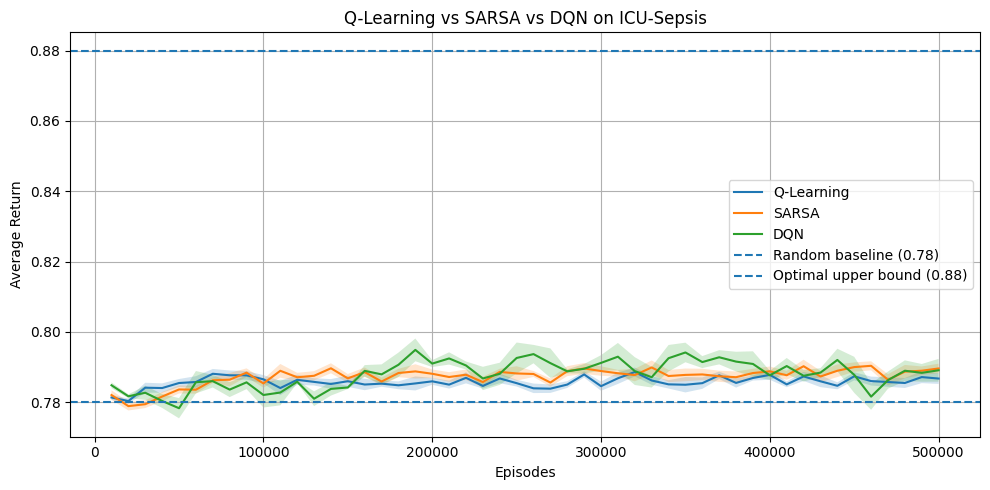

Final results averaged over seeds:
Q-Learning : 0.7867 ± 0.0015  (paper: ~0.84)
SARSA      : 0.7896 ± 0.0014  (paper: ~0.79)
DQN        : 0.7891 ± 0.0032  (paper: ~0.86)


In [ ]:
# ── Step 2.4: Compare Q-Learning, SARSA, and DQN ──────────────────────────────

# Q-Learning and SARSA results from Step 1.4:
# x, mean_ql, se_ql, mean_sa, se_sa

# DQN results from Step 2.3:
# dqn_x, all_dqn, dqn_seeds

all_dqn = np.array(all_dqn)

mean_dqn = all_dqn.mean(axis=0)
se_dqn = all_dqn.std(axis=0, ddof=1) / np.sqrt(len(dqn_seeds))

plt.figure(figsize=(10, 5))

# Q-Learning
plt.plot(x, mean_ql, label="Q-Learning")
plt.fill_between(x, mean_ql - se_ql, mean_ql + se_ql, alpha=0.2)

# SARSA
plt.plot(x, mean_sa, label="SARSA")
plt.fill_between(x, mean_sa - se_sa, mean_sa + se_sa, alpha=0.2)

# DQN
plt.plot(dqn_x, mean_dqn, label="DQN")
plt.fill_between(dqn_x, mean_dqn - se_dqn, mean_dqn + se_dqn, alpha=0.2)

# Paper baselines
plt.axhline(0.78, linestyle="--", label="Random baseline (0.78)")
plt.axhline(0.88, linestyle="--", label="Optimal upper bound (0.88)")

plt.xlabel("Episodes")
plt.ylabel("Average Return")
plt.title("Q-Learning vs SARSA vs DQN on ICU-Sepsis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Final results averaged over seeds:")
print(f"Q-Learning : {mean_ql[-1]:.4f} ± {se_ql[-1]:.4f}  (paper: ~0.84)")
print(f"SARSA      : {mean_sa[-1]:.4f} ± {se_sa[-1]:.4f}  (paper: ~0.79)")
print(f"DQN        : {mean_dqn[-1]:.4f} ± {se_dqn[-1]:.4f}  (paper: ~0.86)")